In [1]:
import numpy as np

import matplotlib.pyplot as plt
import scipy

# %matplotlib notebook 
%matplotlib inline 

import qutip as qutip

# https://qutip.readthedocs.io/en/latest/guide/guide.html
# https://qutip.org/qutip-tutorials/

fileroot = 'HadWalk_00_'

# do the Hadamard random walk problem 

The space is $2 \times N $ dimensional.  This is the tensor product of a two state system with an N state system. 

Controlled shifts:
$$\hat C = P_0 \otimes X + P_1 \otimes X^\dagger $$

with $P_0 = \ket{0}\bra{0}, P_1 = \ket{1}\bra{1}$ and $X$ the Heisenberg shift op.  

$X = \sum_{j=0}^{N-1} \ket{j+1} \bra{j}$ where addition is mod N

Hadamard coin toss:
$ \hat H \otimes \hat I$. 

The walk repeats
$\hat V = (\hat H \otimes \hat I ) \hat C$

In [142]:
# check to see if an np.array square matrix is unitary 
# to call this with a qutip object A, pass A.full()
def is_unitary(m):
    bb = np.allclose(np.eye(len(m)), m.dot(m.T.conj()), rtol=1e-05, atol=1e-08) # for square numpy array m
    return bb  # returns boolean


# makes an operator that is |j><k|
def projection(N,j,k):    
    jj = qutip.basis(N, j) # |j>
    kk = qutip.basis(N, k) # |k>
    return jj*kk.dag()  # |j><k|
    
# Create heisenberg shift operator  X= sum_j |j+1><j|  addition mod N,  (is unitary)
def make_Xp(N):
    A = projection(N,0,N-1)  # this gives a matrix with a single 1 in it
    # the first argument is the dimension of the Hilbert space
    # the second two arguments are i,j giving |i><j|
    for i in range(0,N-1):
        A = A + qutip.projection(N,i+1,i)
    return A

# Create Heisenber shift op: X^dagger,  X^dagger= sum_j |j><j+1|
def make_Xm(N):
    A = make_Xp(N)
    return A.dag()

# return random x Identity in full space 
def make_H_Haar(N):
    R = qutip.random_objects.rand_unitary(2)  # Haar random on 2 state  (single qubit)
    R_full = qutip.tensor((R,qutip.qeye(N))) # R x I 
    return R_full

if (1==0): # tests
    print(projection(3,1,2))
    print(make_Xp(7))    
    print(make_Xm(7)) 


In [143]:
# make an operator that is P0*X + P1*X^dagger 
def make_C(N):
    k0 = qutip.basis(2,0) # |0>
    k1 = qutip.basis(2,1) # |1>
    P0 = k0 * k0.dag()  # make projection operators |0><0|
    P1 = k1 * k1.dag()  # and |1><1|
    P0_full = qutip.tensor([P0,qutip.qeye(N)])
    P1_full = qutip.tensor([P1,qutip.qeye(N)])
    Xp = make_Xp(N) # Heisenberg X operator 
    Xm = Xp.dag()  # X^dagger 
    Xp_full = qutip.tensor((qutip.qeye(2),Xp))
    Xm_full = qutip.tensor((qutip.qeye(2),Xm))
    #print(Xp_full)
    C = P0_full*Xp_full + P1_full*Xm_full 
    print('is unitary? ',is_unitary(C.full()))
    return C 

# return H x Identity in full space 
def make_H(N):
    had = qutip.gates.hadamard_transform() # gives hadamard on two state system
    had_full = qutip.tensor((had,qutip.qeye(N))) # H x I 
    return had_full

if (1==0): # tests
    N=7
    C = make_C(N)
    H = make_H(N)
    #print(C.full())

def prob_N(N,psi):
    nprobs= np.zeros(N)  # allocate a vector of N values
    for i in range(0,N):
        nproj=projection(N,i,i)    # projection operator for state |i> which is |i><i|
        # the first argument is the dimension of the Hilbert space
        v = qutip.tensor((qutip.qeye(2),nproj))  # to take into account both spin possible values
        nprobs[i] = qutip.expect(v,psi)  # probability of being in |n>
    return nprobs  # return the vector of probabilities for each possible measurement 

In [148]:
N = 50
C = make_C(N)
H = make_H(N)

#psi0 = qutip.tensor(qutip.ket('0'),qutip.fock(N,int(N/2)))  # an initial state 
sphase = qutip.Qobj([1, -1j]).unit()
psi0 = qutip.tensor(sphase,qutip.fock(N,int(N/2)))  # an initial state that makes evolution symmetrical 

is unitary?  True


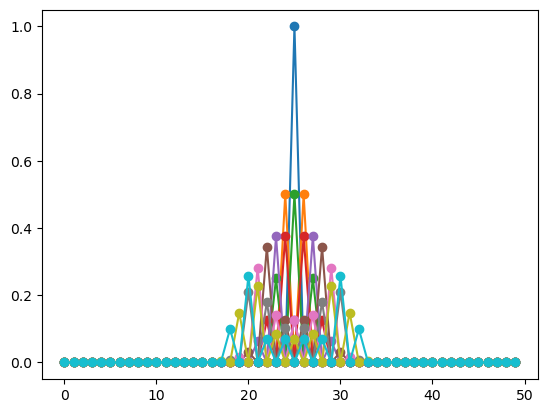

In [149]:
psi = psi0
# run the conventional random walk
fig,ax= plt.subplots(1,1)
for k in range(10):
    probs = prob_N(N,psi)
    ax.plot(probs,'o-')
    V = H*C
    psi = V*psi
plt.show()
    

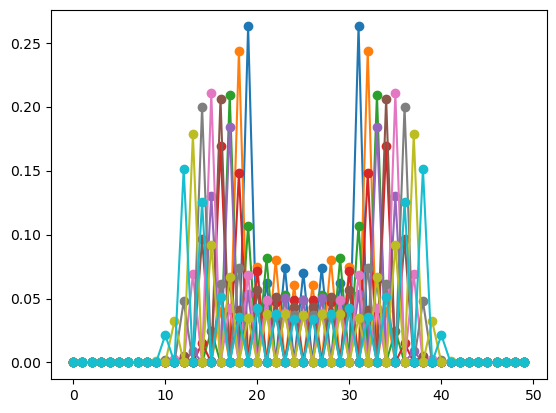

In [150]:
fig,ax= plt.subplots(1,1)
for k in range(10):
    probs = prob_N(N,psi)
    ax.plot(probs,'o-')
    V = H*C
    psi = V*psi
plt.show()

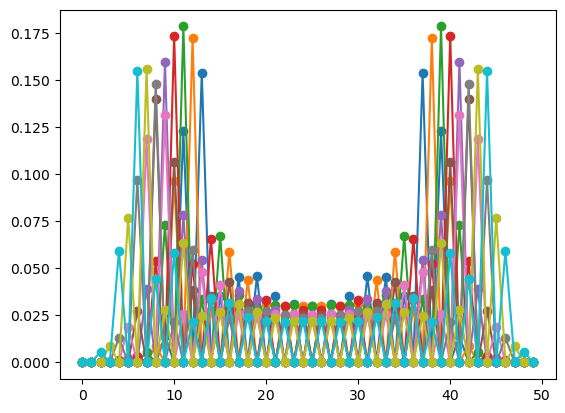

In [151]:
fig,ax= plt.subplots(1,1)
for k in range(10):
    probs = prob_N(N,psi)
    ax.plot(probs,'o-')
    V = H*C
    psi = V*psi
plt.show()

In [152]:

N = 50
C = make_C(N)
#H = make_H(N)
sphase = qutip.Qobj([1, -1j]).unit()
psi0 = qutip.tensor(sphase,qutip.fock(N,int(N/2))) 

is unitary?  True


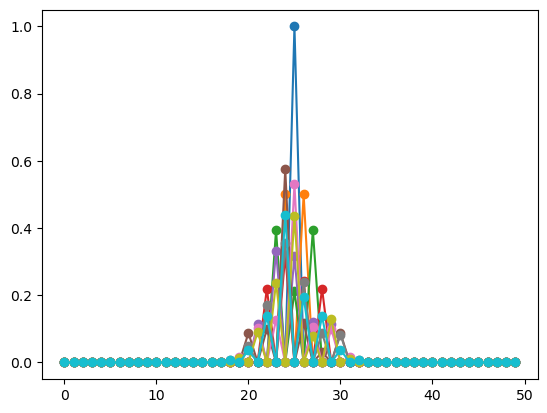

In [153]:
psi = psi0
# run the random matrix version of the random walk
fig,ax= plt.subplots(1,1)
for k in range(10):
    probs = prob_N(N,psi)
    ax.plot(probs,'o-')
    R_full = make_H_Haar(N)
    V = R_full*C
    psi = V*psi
plt.show()

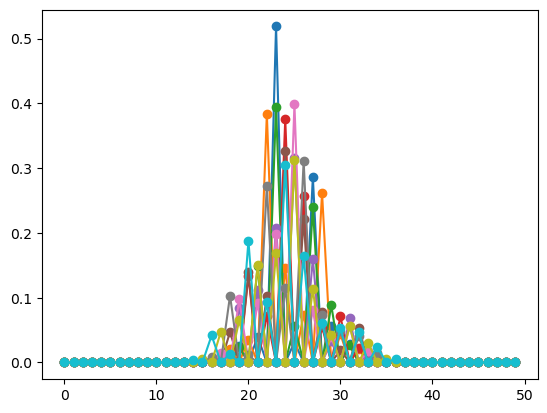

In [154]:
fig,ax= plt.subplots(1,1)
for k in range(10):
    probs = prob_N(N,psi)
    ax.plot(probs,'o-')
    R_full = make_H_Haar(N)
    V = R_full*C
    psi = V*psi
plt.show()

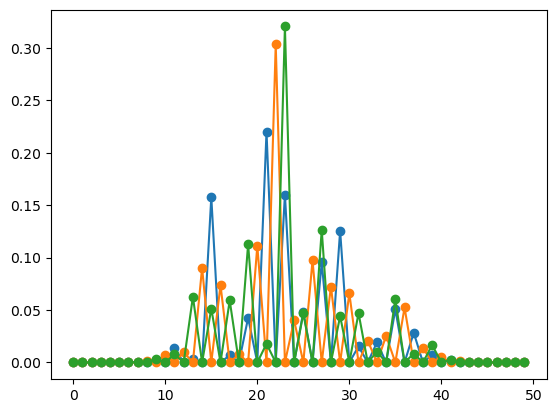

In [159]:
fig,ax= plt.subplots(1,1)
for k in range(3):
    probs = prob_N(N,psi)
    ax.plot(probs,'o-')
    R_full = make_H_Haar(N)
    V = R_full*C
    psi = V*psi
plt.show()